In [8]:
!pip install opencv-python-headless
!pip install scikit-learn matplotlib numpy scipy


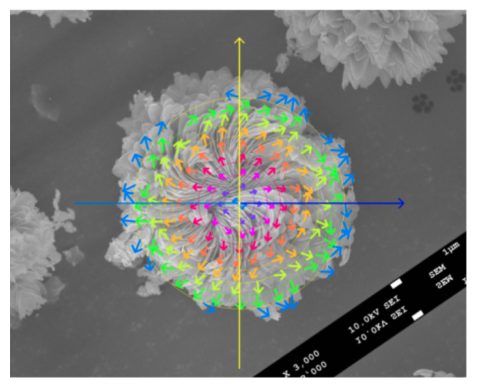

In [1]:
from PIL import Image

import matplotlib.pyplot as plt

# Load image.png
img = Image.open('image.png')
plt.imshow(img)
plt.axis('off')
plt.show()

Center at: (336.00, 284.50)


/var/folders/5r/6f18fbm17wl8t8q50sb5hrvc0000gn/T/ipykernel_25191/1263897385.py:33: RuntimeWarning: overflow encountered in scalar subtract
  denom = (y0 - 2*y1 + y2)
/var/folders/5r/6f18fbm17wl8t8q50sb5hrvc0000gn/T/ipykernel_25191/1263897385.py:36: RuntimeWarning: overflow encountered in scalar subtract
  return float(peak + 0.5 * (y0 - y2) / denom)


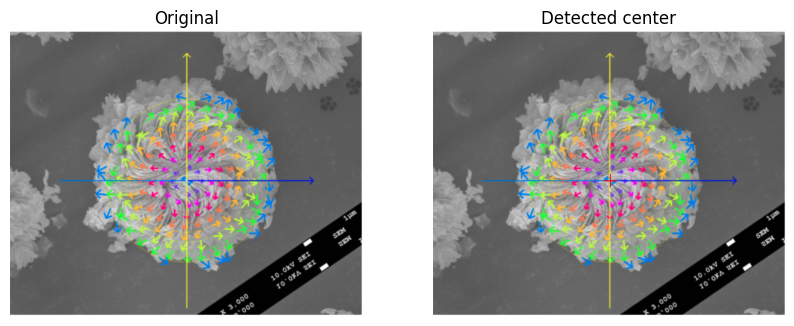

In [2]:
import numpy as np
import cv2
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

def find_crosshair_center_color(pil_img,
                                yellow_range=((15, 80, 120), (45, 255, 255)),
                                blue_range=((90, 50, 70), (135, 255, 255)),
                                refine=True):
    """
    Find intersection of yellow (vertical) and blue (horizontal) axes.
    Returns (x_center, y_center), plus masks for debug.
    """
    bgr = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)

    y_low, y_high = yellow_range
    b_low, b_high = blue_range
    mask_y = cv2.inRange(hsv, np.array(y_low), np.array(y_high))
    mask_b = cv2.inRange(hsv, np.array(b_low), np.array(b_high))

    # Projections
    col_y = mask_y.sum(axis=0)  # vertical line -> peak column
    row_b = mask_b.sum(axis=1)  # horizontal line -> peak row
    x_peak = int(np.argmax(col_y))
    y_peak = int(np.argmax(row_b))

    # Optional subpixel refinement via quadratic fit
    def subpixel_peak(proj, peak):
        if not refine or peak <= 0 or peak >= len(proj)-1:
            return float(peak)
        y0, y1, y2 = proj[peak-1], proj[peak], proj[peak+1]
        denom = (y0 - 2*y1 + y2)
        if denom == 0:
            return float(peak)
        return float(peak + 0.5 * (y0 - y2) / denom)

    x_center = subpixel_peak(col_y, x_peak)
    y_center = subpixel_peak(row_b, y_peak)
    return x_center, y_center, mask_y, mask_b

# Use it
img = Image.open("image.png")
xc, yc, mask_y, mask_b = find_crosshair_center_color(img)
print(f"Center at: ({xc:.2f}, {yc:.2f})")

# Visualize
vis = img.copy()
draw = ImageDraw.Draw(vis)
draw.line((xc-12, yc, xc+12, yc), fill='red', width=2)
draw.line((xc, yc-12, xc, yc+12), fill='red', width=2)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(img); plt.axis('off'); plt.title('Original')
plt.subplot(1,2,2); plt.imshow(vis); plt.axis('off'); plt.title('Detected center')
plt.show()

In [5]:
import ast
# !pip install pandas
import pandas as pd
from pathlib import Path
import numpy as np

# from os import Path

# --- Load data ---
csv_path = Path.cwd().parent / "vf_exports" / "Front_EE-1_1_3000x_rings_coords.csv"
df = pd.read_csv(csv_path)
print(type(df['Coordinate'][0]))

def parse_coord(s):
    if isinstance(s, (list, tuple, np.ndarray)):
        return list(s)
    if not isinstance(s, str):
        return [np.nan, np.nan]
    s = s.strip()
    try:
        val = ast.literal_eval(s)          # handles "(7.00, 0.00)" or "[7.00, 0.00]"
        return list(val)
    except Exception:
        parts = [p.strip() for p in s.strip("()[]").split(",")]
        try:
            return [float(parts[0]), float(parts[1])]
        except Exception:
            return [np.nan, np.nan]
        
angles_deg = df['Angle (α′)'].values 
X = [coord[0] for coord in coordinates]
Y = [coord[1] for coord in coordinates]
# df['Coordinate'] = df['Coordinate'].apply(lambda x: np.array(x))    
coordinates = df['Coordinate'].apply(parse_coord).tolist()
# Find global theta from the coordinates 
theta = np.arctan2(
    np.array(Y),
    np.array(X)
)
phi = angles_deg + np.degrees(theta)


# For these angles and coordinates, plot a vector field


<class 'str'>


<class 'pandas.core.series.Series'>


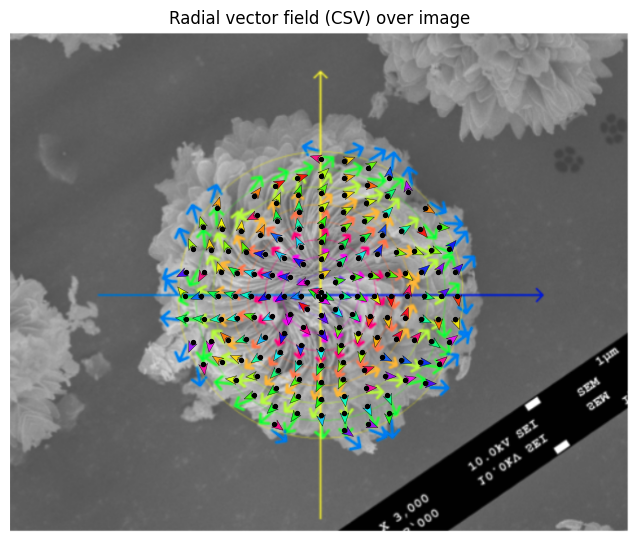

In [11]:
# # !pip install pandas
# import pandas as pd
# from pathlib import Path

# # from os import Path

# # --- Load data ---
csv_path = Path.cwd().parent / "vf_exports" / "Front_EE-1_1_3000x_rings_coords.csv"
df = pd.read_csv(csv_path)
print(type(df['Coordinate']))
# # Parse "(x, y)" strings to floats
# def parse_coord(s):
#     s = s.strip("()")
#     print(s)
#     x_str, y_str = s.split(",")
#     return float(x_str), float(y_str)

# coords = df["Coordinate"].apply(parse_coord)
X_rel = np.array([c[0] for c in coordinates])
Y_rel = np.array([c[1] for c in coordinates])
# angles_deg = df["Angle (α′)"].to_numpy()

# --- Map to pixel space (center = xc, yc) ---
pixels_per_unit = 1.0  # adjust if vectors are too tight/loose
x_pix = xc + pixels_per_unit * X_rel * 0.5
y_pix = yc - pixels_per_unit * Y_rel * 0.5# invert Y for image coords

# --- Vector components (angles given in degrees) ---
phi_rad = np.deg2rad(phi)

arrow_len = 12  # pixels; bump up/down to taste
u = arrow_len * np.cos(phi_rad)
v = -arrow_len * np.sin(phi_rad)  # minus to match image Y direction

# --- Plot on top of the image ---
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.quiver(
    x_pix, y_pix, u, v, angles_deg,
    angles='xy', scale_units='xy', scale=1,
    cmap='hsv', width=0.01, headwidth=8, headlength=10, headaxislength=7,
    alpha=0.9, edgecolor='k', linewidth=0.3
)
plt.scatter(x_pix, y_pix, c='k', s=8, zorder=3)
plt.axis('off')
plt.title("Radial vector field (CSV) over image")
plt.show()

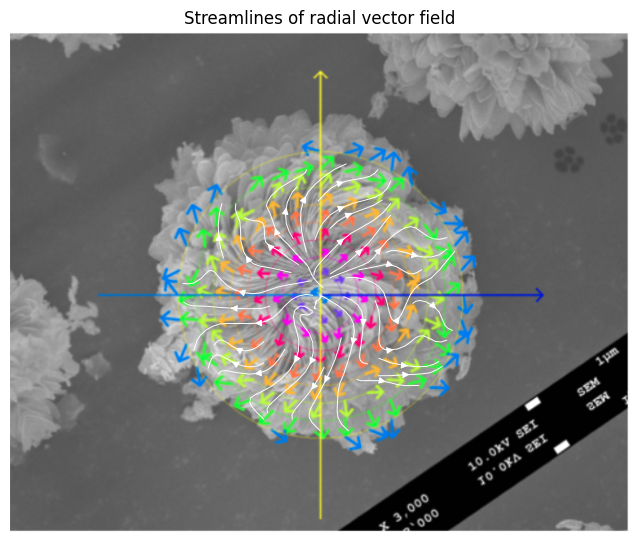

In [8]:
from scipy.interpolate import griddata

# Create a uniform grid
img_array = np.array(img)
height, width = img_array.shape[:2]
grid_x = np.linspace(0, width, 100)
grid_y = np.linspace(0, height, 100)
grid_X, grid_Y = np.meshgrid(grid_x, grid_y)

# Interpolate u and v onto the grid
# Remove NaN values first
valid = ~np.isnan(u) & ~np.isnan(v) & ~np.isnan(x_pix) & ~np.isnan(y_pix)
grid_U = griddata((x_pix[valid], y_pix[valid]), u[valid], (grid_X, grid_Y), method='linear', fill_value=0)
grid_V = griddata((x_pix[valid], y_pix[valid]), v[valid], (grid_X, grid_Y), method='linear', fill_value=0)

# Plot streamplot using the interpolated grid
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.streamplot(
    grid_x, grid_y, grid_U, grid_V,
    color='white', density=1.5, linewidth=0.7, arrowsize=1
)
plt.axis('off')
plt.title("Streamlines of radial vector field")
plt.show()


Using Bandwidth h = nan


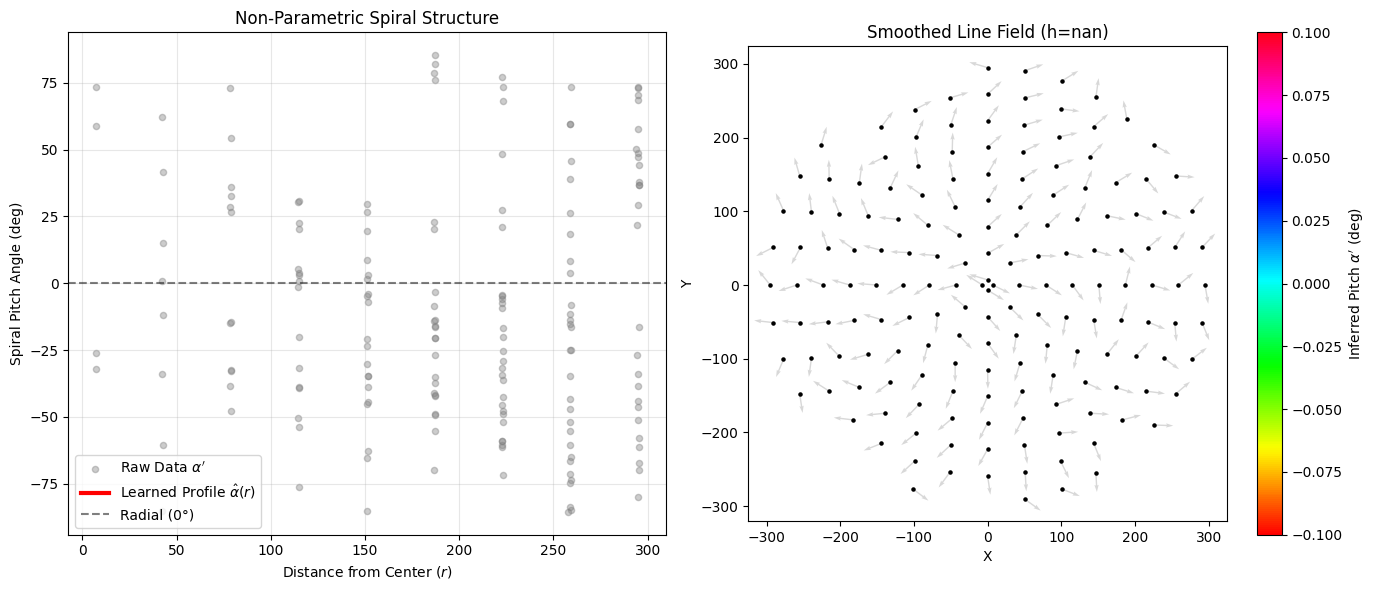

/Users/rishabhkumar/miniconda3/lib/python3.12/site-packages/matplotlib/axes/_axes.py:6973: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/Users/rishabhkumar/miniconda3/lib/python3.12/site-packages/matplotlib/axes/_axes.py:6974: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

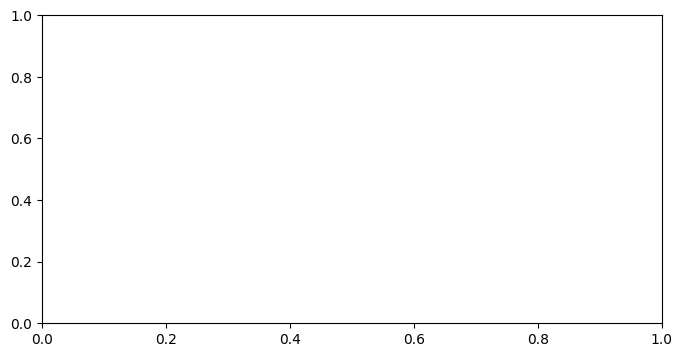

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ast

# --- 1. Data Preparation (Using your parsing logic) ---
# We assume 'df' is your loaded dataframe
# If you need dummy data to run this immediately, uncomment the block below:
# ---------------------------------------------------------
# N = 300
# df = pd.DataFrame()
# # Synthetic data: r roughly 0 to 10
# X_syn = np.random.uniform(-10, 10, N)
# Y_syn = np.random.uniform(-10, 10, N)
# r_syn = np.sqrt(X_syn**2 + Y_syn**2)
# # True structure: pitch decays from 45 deg to 0 deg
# alpha_true = 45 * np.exp(-r_syn/5) + np.random.normal(0, 10, N)
# df['Angle (α′)'] = alpha_true
# df['Coordinate'] = [f"({x:.2f}, {y:.2f})" for x, y in zip(X_syn, Y_syn)]
# ---------------------------------------------------------

def parse_coord(s):
    if isinstance(s, (list, tuple, np.ndarray)):
        return list(s)
    if not isinstance(s, str):
        return [np.nan, np.nan]
    s = s.strip()
    try:
        val = ast.literal_eval(s)
        return list(val)
    except Exception:
        parts = [p.strip() for p in s.strip("()[]").split(",")]
        try:
            return [float(parts[0]), float(parts[1])]
        except Exception:
            return [np.nan, np.nan]

coordinates = df['Coordinate'].apply(parse_coord).tolist()
X = np.array([coord[0] for coord in coordinates])
Y = np.array([coord[1] for coord in coordinates])

# Compute Spatial Parameters
r_obs = np.sqrt(X**2 + Y**2)
theta_spatial = np.arctan2(Y, X) # Radians

# Observed Relative Angle (Pitch) in Radians
# We use this directly for smoothing
alpha_obs_deg = df['Angle (α′)'].values
alpha_obs_rad = np.radians(alpha_obs_deg)

# --- 2. The Line-Field Kernel Smoother ---

def gaussian_kernel(u):
    return (1.0 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

# def epchanovik_kernel(u):

def smooth_spiral_pitch(target_r, sample_r, sample_alpha_rad, bandwidth):
    """
    Smooths the relative spiral angle alpha using double-angle metric
    to respect line field symmetry (alpha == alpha + pi).
    """
    # Map to double angle space (2*alpha)
    # This maps 90 deg and -90 deg to the same vector in the embedding space
    cos_2alpha = np.cos(2 * sample_alpha_rad)
    sin_2alpha = np.sin(2 * sample_alpha_rad)
    
    # Kernel weights
    u = (target_r[:, None] - sample_r[None, :]) / bandwidth
    weights = gaussian_kernel(u)
    
    sum_weights = np.sum(weights, axis=1)
    # Handle data gaps
    sum_weights[sum_weights < 1e-10] = 1.0 
    
    # Weighted average of components
    avg_cos = np.sum(weights * cos_2alpha[None, :], axis=1) / sum_weights
    avg_sin = np.sum(weights * sin_2alpha[None, :], axis=1) / sum_weights
    
    # Recover angle: atan2 gives (-pi, pi], divide by 2 gives (-pi/2, pi/2]
    alpha_est = 0.5 * np.arctan2(avg_sin, avg_cos)
    
    return alpha_est

# --- 3. Execution ---

# Setup Grid
r_grid = np.linspace(0, np.max(r_obs), 100)

# Tunable Hyperparameter (Bandwidth)
# Since coordinates look like they range 0-10 or 0-100, pick reasonable scale
# If X is ~2000 units, b should be ~200. If X is ~10 units, b ~ 1.0.
bandwidth = np.percentile(r_obs, 90) / 10.0 
print(f"Using Bandwidth h = {bandwidth:.2f}")

# 1. Learn the Structure Function alpha(r)
alpha_fitted_rad_grid = smooth_spiral_pitch(r_grid, r_obs, alpha_obs_rad, bandwidth)

# 2. Predict on original points (for residuals/plotting)
alpha_fitted_rad = smooth_spiral_pitch(r_obs, r_obs, alpha_obs_rad, bandwidth)

# 3. Reconstruct Global Field vectors
# phi_fitted = theta_spatial + alpha_fitted(r)
phi_fitted_rad = theta_spatial + alpha_fitted_rad
U_fit = np.cos(phi_fitted_rad)
V_fit = np.sin(phi_fitted_rad)

# --- 4. Visualization ---

plt.figure(figsize=(14, 6))

# Subplot 1: The Structure Function (The Physics)
# This shows exactly how the spiral pitch changes with distance
plt.subplot(1, 2, 1)
# Wrap observed alphas to [-90, 90] for consistent plotting
alpha_obs_wrapped = np.degrees(np.arctan(np.tan(alpha_obs_rad)))
plt.scatter(r_obs, alpha_obs_wrapped, c='gray', alpha=0.4, s=20, label='Raw Data $\\alpha\'$')
plt.plot(r_grid, np.degrees(alpha_fitted_rad_grid), color='red', linewidth=3, label='Learned Profile $\\hat{\\alpha}(r)$')
plt.axhline(0, color='k', linestyle='--', alpha=0.5, label='Radial (0°)')
plt.xlabel('Distance from Center ($r$)')
plt.ylabel('Spiral Pitch Angle (deg)')
plt.title('Non-Parametric Spiral Structure')
plt.legend()
plt.grid(alpha=0.3)

# Subplot 2: The Vector Field Comparison
ax2 = plt.subplot(1, 2, 2)

# Plot Original Noisy Field (Gray/Thin)
phi_obs_rad = np.radians(df['Angle (α′)'].values) + theta_spatial
U_raw = np.cos(phi_obs_rad)
V_raw = np.sin(phi_obs_rad)
plt.quiver(X, Y, U_raw, V_raw, color='gray', alpha=0.3, 
           scale=25, width=0.003, headwidth=3)

# Plot Fitted Smooth Field (Colored/Thick)
# Using headwidth=0 to denote Line Field (Director field)
q = plt.quiver(X, Y, U_fit, V_fit, np.degrees(alpha_fitted_rad),
           angles='xy', scale_units='xy', scale=1, cmap='hsv',
           width=0.01, headwidth=0, pivot='mid') # Headless vectors

plt.colorbar(q, label='Inferred Pitch $\\alpha\'$ (deg)')
plt.scatter(X, Y, c='k', s=5, zorder=3)
ax2.set_aspect('equal')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Smoothed Line Field (h={bandwidth:.2f})')

plt.tight_layout()
plt.show()

# --- 5. Residual Analysis (Mod Pi) ---
# Calculate error in [-pi/2, pi/2]
error_rad = alpha_obs_rad - alpha_fitted_rad
residuals = np.mod(error_rad + np.pi/2, np.pi) - np.pi/2
residuals_deg = np.degrees(residuals)

plt.figure(figsize=(8, 4))
plt.hist(residuals_deg, bins=30, color='purple', alpha=0.7, density=True)
plt.axvline(0, color='k', linestyle='--')
plt.xlabel('Residual Error (degrees)')
plt.ylabel('Density')
plt.title('Residuals Distribution (Mod 180°)')
plt.grid(alpha=0.3)
plt.show()